In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cat /etc/*release

DISTRIB_ID=Ubuntu
DISTRIB_RELEASE=22.04
DISTRIB_CODENAME=jammy
DISTRIB_DESCRIPTION="Ubuntu 22.04.5 LTS"
PRETTY_NAME="Ubuntu 22.04.5 LTS"
NAME="Ubuntu"
VERSION_ID="22.04"
VERSION="22.04.5 LTS (Jammy Jellyfish)"
VERSION_CODENAME=jammy
ID=ubuntu
ID_LIKE=debian
HOME_URL="https://www.ubuntu.com/"
SUPPORT_URL="https://help.ubuntu.com/"
BUG_REPORT_URL="https://bugs.launchpad.net/ubuntu/"
PRIVACY_POLICY_URL="https://www.ubuntu.com/legal/terms-and-policies/privacy-policy"
UBUNTU_CODENAME=jammy


In [ ]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


## Display image


In [ ]:
# @title Upload your image
import os

RES_DIR = '/content/data'
FRAMES_DIR = os.path.join(RES_DIR, 'images')
!rm -rf $RES_DIR
!mkdir $RES_DIR
!mkdir $FRAMES_DIR

In [ ]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# @title Input your data in /content/data/images
filename =     "sample3.png"# @param {type:'string'}

def load_img(img_path):
  return np.asarray(Image.open(img_path))/255

# Check if FRAMES_DIR is empty and create a dummy image if it is
# if not os.listdir(FRAMES_DIR):
#   print(f"Warning: '{FRAMES_DIR}' is empty. Creating a dummy 'sample.jpg' for demonstration.")
#   dummy_img = Image.new('RGB', (100, 100), color = 'red')
#   dummy_img_path = os.path.join(FRAMES_DIR, filename)
#   dummy_img.save(dummy_img_path)

test_img_path = '/content/drive/MyDrive/sample2.jpg'

test_img = load_img(test_img_path)

plt.figure(figsize=(5, 10))
plt.title("extracted image example")
plt.imshow(test_img)

In [ ]:
# @title Install SMPLify-X and other dependencies

%cd /content
!pip install chumpy
!pip install smplx[all]
!git clone https://github.com/vchoutas/smplx
%cd smplx
!python setup.py install

#vposer
!pip install git+https://github.com/nghorbani/configer
!pip install git+https://github.com/nghorbani/human_body_prior
#!pip install git+https://github.com/sergeyprokudin/human_body_prior

#!pip install torch==1.1.0
%cd /content
#!git clone https://github.com/sergeyprokudin/smplify-x
!git clone https://github.com/KyujinHan/Smplify-X-Perfect-Implementation
%cd /content/Smplify-X-Perfect-Implementation
!pip install -r requirements.txt # Error is okay. Just pass.

/content
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.6/50.6 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for chumpy: filename=chumpy-0.70-py3-none-any.whl size=58263 sha256=83fc6cdd0b9d69e83bc6dc92b5d7c129507a49ea8e27cd37750fab7417e8df18
  Stored in directory: /root/.cache/pip/wheels/ae/b7/0e/6f56330e9077b8a6aad99bdb76981b07a7e8b3f056def662a6
Successfully built chumpy
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 87.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 65.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.8/740.8 kB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 80.7 MB/s eta 0:00:00
  Created wheel for PyOpenGL: filename=PyOpenGL-3.1.0-py3-none-any.whl size=1

In [ ]:
import os
os.kill(os.getpid(), 9)

In [ ]:
# @title Upload the SMPL-X model files

# @markdown Proceed to the [official website](https://smpl-x.is.tue.mpg.de/), register and download the zip files with SMPL-X (**models_smplx_v1_1.zip**, ~830MB) and VPoser (**vposer_v1_0.zip**, ~2.5MB) models from the **Downloads** section.
# @markdown

# @markdown Since uploading large zip files to Colab is relatively slow, we expect you to upload these files to Google Drive instead, link gdrive to the Colab file systems and modify **SMPLX_ZIP_PATH** and **VPOSER_ZIP_PATH** variables accordingly.

%cd /content/
from google.colab import drive
drive.mount('/content/gdrive')

!mkdir /content/gdrive/MyDrive/smplify-x/
!mkdir /content/gdrive/MyDrive/smplify-x/vposer
!mkdir /content/gdrive/MyDrive/smplify-x/smplx

SMPLX_ZIP_PATH = '/content/gdrive/MyDrive/smplify-x/smplx/models_smplx_v1_1.zip' # @param {type:"string"}
VPOSER_ZIP_PATH = '/content/gdrive/MyDrive/smplify-x/vposer/V02_05.zip' # @param {type:"string"}

SMPLX_MODEL_PATH = '/content/smplx'
!mkdir $SMPLX_MODEL_PATH
!unzip -n $SMPLX_ZIP_PATH -d $SMPLX_MODEL_PATH
VPOSER_MODEL_PATH = '/content/vposer'
!mkdir $VPOSER_MODEL_PATH
!unzip -n $VPOSER_ZIP_PATH -d $VPOSER_MODEL_PATH

/content
Mounted at /content/gdrive
mkdir: cannot create directory ‘/content/gdrive/MyDrive/smplify-x/’: File exists
mkdir: cannot create directory ‘/content/gdrive/MyDrive/smplify-x/vposer’: File exists
mkdir: cannot create directory ‘/content/gdrive/MyDrive/smplify-x/smplx’: File exists
mkdir: cannot create directory ‘/content/smplx’: File exists
Archive:  /content/gdrive/MyDrive/smplify-x/smplx/models_smplx_v1_1.zip
   creating: /content/smplx/models/
   creating: /content/smplx/models/smplx/
  inflating: /content/smplx/models/smplx/SMPLX_NEUTRAL.npz  
 extracting: /content/smplx/models/smplx/version.txt  
  inflating: /content/smplx/models/smplx/SMPLX_MALE.pkl  
  inflating: /content/smplx/models/smplx/SMPLX_FEMALE.npz  
 extracting: /content/smplx/models/smplx/smplx_npz.zip  
  inflating: /content/smplx/models/smplx/SMPLX_MALE.npz  
  inflating: /content/smplx/models/smplx/SMPLX_FEMALE.pkl  
  inflating: /content/smplx/models/smplx/SMPLX_NEUTRAL.pkl  
Archive:  /content/gdrive/MyD

In [ ]:
!pip install configargparse
!pip install omegaconf
!pip install loguru

DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/smplx-0.1.28-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/smplx-0.1.28-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/smplx-0.1.28-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330


In [ ]:
# @title Run SMPLify-X

# @markdown Please select gender of the SMPL-X model:

gender = 'female' #@param ["neutral", "female", "male"]

# @markdown Please keep in mind that estimating 3D body with SMPLify-X framework will take ~30-60 secs.
# @markdown Make sure the keypoints and images have been uploaded.

!rm -rf /content/data/smplifyx_results
%cd /content/Smplify-X-Perfect-Implementation
!git pull origin

!python smplifyx/main.py --config cfg_files/fit_smplx.yaml \
    --data_folder  /content/data \
    --output_folder /content/data/smplifyx_results \
    --visualize=True \
    --gender=$gender \
    --model_folder /content/smplx/models/ \
    --vposer_ckpt /content/vposer/V02_05\
    --part_segm_fn smplx_parts_segm.pkl

/content/Smplify-X-Perfect-Implementation
Already up to date.
Processing: /content/data/images/sample2.jpg
/content/vposer/V02_05
/usr/local/lib/python3.12/dist-packages/human_body_prior/tools/model_loader.py:80: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. 

# mesh generate

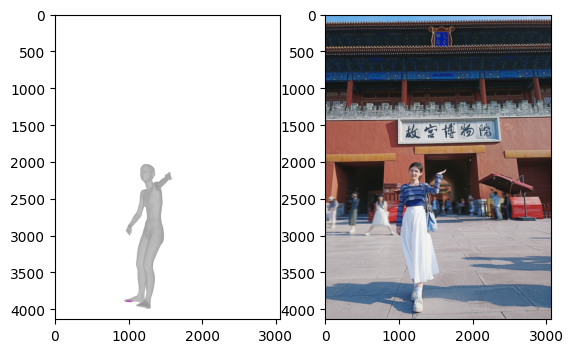

In [ ]:
## image
import matplotlib.pyplot as plt
from PIL import Image
fig = plt.figure()
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

img1 = Image.open('/content/data/smplifyx_results/rendered_smplifyx_meshes/00000.png')
img2 = Image.open('/content/data/images/sample2.jpg')
ax1.imshow(img1)
ax2.imshow(img2)

In [ ]:
import pickle
import numpy as np
import torch
import smplx

IN_PKL = "/content/data/smplifyx_results/results/sample2/000.pkl"
OUT_PKL = "/content/data/result_apose.pkl"
MODEL_DIR = r"/content/smplx/models/smplx/SMPLX_FEMALE.npz"   # 放 SMPLX_NEUTRAL.npz 的目录
GENDER = "female"               # 按你的拟合结果改

with open(IN_PKL, "rb") as f:
    d = pickle.load(f)

model = smplx.create(
    model_path=MODEL_DIR,
    model_type="smplx",
    gender=GENDER,
    use_pca=False,
    flat_hand_mean=False,  # 用手部均值更自然
    batch_size=1
)

pose_mean = model.pose_mean.detach().cpu().numpy().reshape(-1)

# SMPL-X pose 维度切片：
# global_orient: 0:3
# body_pose: 3:66
# jaw: 66:69, leye: 69:72, reye: 72:75
# left_hand: 75:120, right_hand: 120:165
d["body_pose"] = pose_mean[3:66].copy()

# 可选：手部也改为均值（避免奇怪手势）
if "left_hand_pose" in d:
    d["left_hand_pose"] = pose_mean[75:120].copy()
if "right_hand_pose" in d:
    d["right_hand_pose"] = pose_mean[120:165].copy()

# 可选：想要标准“正站立”可清零世界位姿
# d["global_orient"] = np.zeros(3, dtype=np.float32)
# d["transl"] = np.zeros(3, dtype=np.float32)

with open(OUT_PKL, "wb") as f:
    pickle.dump(d, f)

print("saved:", OUT_PKL)

saved: /content/data/result_apose.pkl


In [ ]:
import pickle
with open("/content/data/result_apose.pkl", "rb") as f:
    data = pickle.load(f)
print(type(data))
print(data.keys() if isinstance(data, dict) else "not dict")

<class 'dict'>
dict_keys(['camera_rotation', 'camera_translation', 'betas', 'global_orient', 'left_hand_pose', 'right_hand_pose', 'jaw_pose', 'leye_pose', 'reye_pose', 'expression', 'body_pose'])


In [ ]:
import pickle
import numpy as np
import torch
import smplx

PKL_PATH = "/content/data/result_apose.pkl"
MODEL_DIR = r"/content/smplx/models/smplx/SMPLX_FEMALE.npz"   # 这里放 SMPLX_NEUTRAL.npz
OUT_PATH = "/content/data/smplx_rig_data.npz"
GENDER = "female"               # 或 male/female，按你的拟合结果改

def to_tensor(x, dim=None):
    if x is None:
        if dim is None:
            return None
        return torch.zeros(1, dim, dtype=torch.float32)
    if isinstance(x, torch.Tensor):
        t = x.detach().cpu().float()
    else:
        t = torch.tensor(np.array(x), dtype=torch.float32)
    if t.ndim == 1:
        t = t.unsqueeze(0)
    if dim is not None:
        if t.shape[1] < dim:
            pad = torch.zeros((t.shape[0], dim - t.shape[1]), dtype=torch.float32)
            t = torch.cat([t, pad], dim=1)
        else:
            t = t[:, :dim]
    return t

with open(PKL_PATH, "rb") as f:
    d = pickle.load(f)

model = smplx.create(
    model_path=MODEL_DIR,
    model_type="smplx",
    gender=GENDER,
    num_betas=10,
    use_pca=False,
    flat_hand_mean=True,
    batch_size=1
)

betas = to_tensor(d.get("betas"), 10)
global_orient = to_tensor(d.get("global_orient"), 3)
body_pose = to_tensor(d.get("body_pose"), 63)
left_hand_pose = to_tensor(d.get("left_hand_pose"), 45)
right_hand_pose = to_tensor(d.get("right_hand_pose"), 45)
jaw_pose = to_tensor(d.get("jaw_pose"), 3)
leye_pose = to_tensor(d.get("leye_pose"), 3)
reye_pose = to_tensor(d.get("reye_pose"), 3)
transl = to_tensor(d.get("transl"), 3)
expression = to_tensor(d.get("expression"), 10)

out = model(
    betas=betas,
    global_orient=global_orient,
    body_pose=body_pose,
    left_hand_pose=left_hand_pose,
    right_hand_pose=right_hand_pose,
    jaw_pose=jaw_pose,
    leye_pose=leye_pose,
    reye_pose=reye_pose,
    transl=transl,
    expression=expression,
    return_verts=True
)

# 常用55个关节（身体+手+脸基础）
J = 55
np.savez(
    OUT_PATH,
    verts=out.vertices[0].cpu().numpy(),
    joints=out.joints[0, :J].cpu().numpy(),
    faces=model.faces.astype(np.int32),
    weights=model.lbs_weights[:, :J].cpu().numpy(),
    parents=model.parents[:J].cpu().numpy()
)
print("saved:", OUT_PATH)

saved: /content/data/smplx_rig_data.npz
